Using device: cpu
Training...
Iteration: 200/1000 | Loss: 0.7874
Iteration: 400/1000 | Loss: 0.5754
Iteration: 600/1000 | Loss: 0.8022
Iteration: 800/1000 | Loss: 0.8477
Iteration: 1000/1000 | Loss: 0.2181
Input: A B C D
Output: D C B B <EOS>


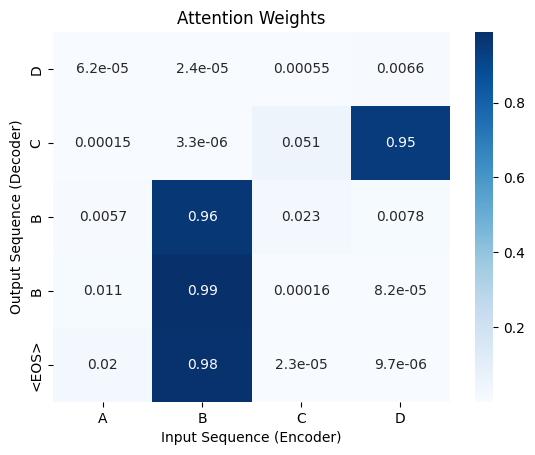

Input: E D C A
Output: A C D E <EOS>


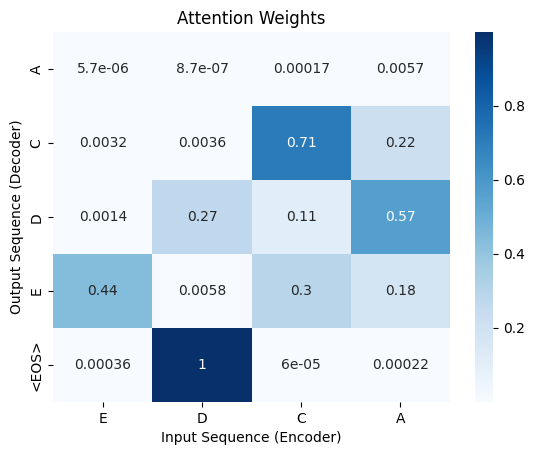

In [1]:
# @title Install and Import Dependencies
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. DATA PREPARATION (Toy Task: Sequence Reversal) ---
# We want the model to learn to reverse the input.
# Input: "A B C" -> Target: "C B A"
# This creates a clear diagonal attention pattern.

SOS_token = 0  # Start of Sentence
EOS_token = 1  # End of Sentence

# Vocabulary
vocab = {"SOS": 0, "EOS": 1, "A": 2, "B": 3, "C": 4, "D": 5, "E": 6}
index2word = {v: k for k, v in vocab.items()}
vocab_size = len(vocab)

# Generate training data
def generate_data(num_samples=100):
    data = []
    keys = list(vocab.keys())
    keys.remove("SOS")
    keys.remove("EOS")

    for _ in range(num_samples):
        seq_len = random.randint(3, 6)
        seq = [vocab[random.choice(keys)] for _ in range(seq_len)]
        input_tensor = torch.tensor(seq, dtype=torch.long, device=device).view(-1, 1)
        target_tensor = torch.tensor(seq[::-1] + [EOS_token], dtype=torch.long, device=device).view(-1, 1)
        data.append((input_tensor, target_tensor))
    return data

training_data = generate_data()

# --- 2. MODEL DEFINITION ---

class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, max_length=10):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.max_length = max_length

        self.embedding = nn.Embedding(self.output_size, self.hidden_size)

        # Attention weights layer
        self.attn = nn.Linear(self.hidden_size * 2, self.max_length)
        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)

        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)

        # Calculate Attention Weights
        # We concatenate embedded input and previous hidden state
        attn_weights = F.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)

        # Apply Attention Weights to Encoder Outputs
        attn_applied = torch.bmm(attn_weights.unsqueeze(0),
                                 encoder_outputs.unsqueeze(0))

        # Combine embedded input and attention result
        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)
        output = F.relu(output)

        output, hidden = self.gru(output, hidden)
        output = F.log_softmax(self.out(output[0]), dim=1)

        return output, hidden, attn_weights

# --- 3. TRAINING FUNCTION ---

def train_model(encoder, decoder, n_iters=1000, learning_rate=0.01):
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    print("Training...")
    for iter in range(1, n_iters + 1):
        input_tensor, target_tensor = random.choice(training_data)

        encoder_hidden = encoder.initHidden()
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        # Encoder
        encoder_outputs = torch.zeros(10, encoder.hidden_size, device=device)
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decoder
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        loss = 0

        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di] # Teacher forcing

        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()

        if iter % 200 == 0:
            print(f"Iteration: {iter}/{n_iters} | Loss: {loss.item()/target_length:.4f}")

# Initialize and Train
hidden_size = 256
encoder = EncoderRNN(vocab_size, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, vocab_size).to(device)

train_model(encoder, decoder, n_iters=1000)

# --- 4. VISUALIZATION OF ATTENTION ---

def evaluate_and_show_attention(input_sentence_str):
    with torch.no_grad():
        # Prepare input
        input_seq = [vocab[c] for c in input_sentence_str.split()]
        input_tensor = torch.tensor(input_seq, dtype=torch.long, device=device).view(-1, 1)
        input_length = input_tensor.size(0)

        # Encode
        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(10, encoder.hidden_size, device=device)
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decode
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []
        decoder_attentions = torch.zeros(10, 10) # Max length 10

        for di in range(10):
            decoder_output, decoder_hidden, attn_weights = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            decoder_attentions[di] = attn_weights.data

            topv, topi = decoder_output.data.topk(1)
            if topi.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            else:
                decoded_words.append(index2word[topi.item()])

            decoder_input = topi.detach()

        # Plotting
        print(f"Input: {input_sentence_str}")
        print(f"Output: {' '.join(decoded_words)}")

        # Set up plot
        fig, ax = plt.subplots()
        # Crop the attention matrix to the actual length of sentences
        attention_plot = decoder_attentions[:len(decoded_words), :len(input_seq)]

        sns.heatmap(attention_plot.cpu().numpy(), annot=True, cmap='Blues', ax=ax,
                    xticklabels=input_sentence_str.split(),
                    yticklabels=decoded_words)

        plt.xlabel('Input Sequence (Encoder)')
        plt.ylabel('Output Sequence (Decoder)')
        plt.title('Attention Weights')
        plt.show()

# Test with a sample input
# We expect the model to reverse this sequence: "A B C D" -> "D C B A"
evaluate_and_show_attention("A B C D")
evaluate_and_show_attention("E D C A")